# EDA — Avance 1: LADDER Attack Pattern Dataset
**Integrantes**: 
- A01796095 Alicia Canta Pandal
- A01328387 Miguel Silva Ramos
- A01370358 Marco Antonio Corona Ruiz

**Proyecto:** LADDER — *Looking Beyond IoCs* (RAID 2023)  
**Datasets:** `sentence_classification` · `entity_extraction` · `attack-pattern-matching-gt`  
**Entorno:** Google Colab  

> Sube los archivos del repositorio a `/content/` antes de ejecutar:  
> `sentence_classification/` · `entity_extraction/` · `attack-pattern-matching-gt.csv`


## Descripción de los datasets utilizados

El proyecto **LADDER** (*Looking Beyond IoCs*, RAID 2023) proporciona tres datasets complementarios,
diseñados para cubrir las etapas de un pipeline de extracción automática de patrones de ataque a partir
de reportes de inteligencia de amenazas cibernéticas (CTI). A continuación se describe cada uno, su
estructura, propósito y el contexto específico de uso en este análisis exploratorio.

---

### Matriz de datasets

| Atributo | `sentence_classification` | `entity_extraction` | `attack-pattern-matching-gt` |
|---|---|---|---|
| **Propósito** | Determinar si una oración contiene una descripción de acción de ataque | Localizar el fragmento exacto (span) que describe la acción maliciosa | Asociar texto con la técnica MITRE ATT&CK correspondiente |
| **Tarea NLP** | Clasificación binaria de texto | Reconocimiento de entidades (NER) | Clasificación multi-clase / recuperación de información |
| **Variable objetivo** | `label` ∈ {0, 1} | `label` ∈ {`ATK`, `O`} por token | `label` = ID de técnica MITRE (ej. `T1636`) |
| **Formato** | CSV con separador TAB (`text`, `label`) | IOB/IOB2 — un token por línea, oraciones separadas por línea vacía | CSV (`text`, `malware`, `label`) |
| **Particiones** | train / dev / test | train / dev / test | Sin partición (ground-truth fijo) |
| **Volumen** | 3,444 oraciones total | 1,800 oraciones / 39,034 tokens total | 81 muestras |
| **Balance** | 50 % positivo / 50 % negativo | ~91 % `O` / ~9 % `ATK` (desbalanceado) | 19 familias × 31 técnicas MITRE |
| **Fuente** | Reportes CTI de malware bancario móvil | Idem — anotación a nivel token | Subset curado para evaluación de mapeo |

---

### ¿Por qué y cuándo se usa cada dataset?

#### 1. `sentence_classification` — *Filtrado semántico*
> **¿Por qué?** Los reportes CTI contienen texto heterogéneo: descripciones técnicas, contexto histórico,
> notas legales, etc. Solo un subconjunto de oraciones describe acciones de ataque concretas.
> Este dataset permite entrenar un **modelo de filtrado binario** que descarte el ruido antes de las etapas
> posteriores, reduciendo el costo computacional y mejorando la precisión del pipeline.
>
> **¿Cuándo se usa?** Es el **primer paso del pipeline**: actúa como puerta de entrada al sistema.
> Se usa en los ítems 1, 2, 3, 4 (balance), 6 (outliers), 7 (distribución), 8 (vocabulario) y 9 (relación longitud-clase).

#### 2. `entity_extraction` — *Localización del span de ataque*
> **¿Por qué?** Una vez identificada la oración relevante, es necesario localizar el fragmento específico
> que describe la acción maliciosa (ej. *"steal SMS messages"*). Este dataset etiqueta cada token con
> `ATK` (pertenece al span de ataque) u `O` (fuera del span), entrenando un modelo **NER** que proporciona
> la entrada precisa para el mapeo a MITRE ATT&CK.
>
> **¿Cuándo se usa?** Es el **segundo paso del pipeline**. Se usa en los ítems 1, 2, 3 (longitud de secuencias),
> 4 (distribución de tokens ATK/O) y 7 (distribución de tokens por oración).

#### 3. `attack-pattern-matching-gt` — *Ground-truth de mapeo MITRE ATT&CK*
> **¿Por qué?** Este dataset proporciona pares *(fragmento de texto, técnica MITRE)* validados manualmente,
> funcionando como **referencia de evaluación** para el modelo de mapeo final. Cubre 19 familias de malware
> bancario móvil (Cerberus, Ginp, Anubis, etc.) y 31 técnicas ATT&CK distintas, lo que permite medir
> la capacidad del sistema para generalizar entre familias y técnicas no vistas durante el entrenamiento.
>
> **¿Cuándo se usa?** Es el **tercer paso del pipeline** y el referente de evaluación end-to-end.
> Se usa en los ítems 1, 5 (cardinalidad) y 9 (diversidad táctica por malware).

---

### Relación entre datasets y flujo del pipeline

```
Reporte CTI (texto libre)
         │
         ▼  [sentence_classification]
  Oraciones con acción de ataque  ←──── Descartar ruido (label=0)
         │
         ▼  [entity_extraction]
  Span exacto de la acción maliciosa  ←── Extraer tokens ATK
         │
         ▼  [attack-pattern-matching-gt]
  Técnica MITRE ATT&CK  ←──── Mapear texto → taxonomía
         │
         ▼
  Anotación estructurada MITRE ATT&CK
```

> **Nota metodológica:** Los tres datasets provienen del mismo corpus de reportes CTI sobre malware bancario
> móvil para Android, lo que garantiza coherencia semántica entre etapas. Sin embargo, el ground-truth de
> mapeo (81 muestras) es considerablemente más pequeño que los datasets de clasificación y NER,
> lo que implica que la evaluación del Paso 3 tiene menor potencia estadística y puede requerir
> técnicas de *few-shot learning* o *retrieval-augmented* para un rendimiento robusto.


## 0. Instalación de dependencias y carga de datos

In [ ]:
!pip install pandas matplotlib seaborn -q

from pathlib import Path
from collections import Counter
import csv, re, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 110, "figure.facecolor": "white"})

# Detección de entorno (Colab vs Local)
if Path("/content").exists():
    BASE = Path("/content")
    print("Entorno: Google Colab detectado.")
else:
    # Local: Buscamos la carpeta de datos del proyecto LADDER
    # El notebook está en PI_team11/, los datos en ../attack_pattern/data
    posibles_rutas = [
        Path("../attack_pattern/data"),
        Path("./attack_pattern/data"),
        Path("attack_pattern/data")
    ]
    BASE = Path(".")
    for p in posibles_rutas:
        if (p / "sentence_classification").exists():
            BASE = p
            break
    print(f"Entorno local detectado. Base: {BASE.absolute()}")

SC_DIR  = BASE / "sentence_classification"
EE_DIR  = BASE / "entity_extraction"
AP_PATH = BASE / "attack-pattern-matching-gt.csv"

def load_sc(path):
    df = pd.read_csv(path, sep="\t", encoding="utf-8")
    df["label"] = df["label"].astype(str)
    df["word_count"] = df["text"].str.split().str.len()
    df["char_count"] = df["text"].str.len()
    return df

def load_ee_tokens(path):
    rows, sents, cur = [], [], []
    with open(path, encoding="utf-8", errors="replace") as f:
        for raw in f:
            line = raw.rstrip("\n")
            if not line.strip():
                if cur: sents.append(cur); cur = []
                continue
            parts = line.rsplit(" ", 1)
            if len(parts) == 2:
                cur.append(parts)
    if cur: sents.append(cur)
    for i, s in enumerate(sents):
        for t, l in s:
            rows.append({"token": t, "label": l, "sent_id": i, "sent_len": len(s)})
    return pd.DataFrame(rows), sents

sc = {s: load_sc(SC_DIR / f"{s}.csv") for s in ("train","dev","test")}
ee, ee_sents = {}, {}
for s in ("train","dev","test"):
    ee[s], ee_sents[s] = load_ee_tokens(EE_DIR / f"{s}.txt")
ap = pd.read_csv(AP_PATH)
ap["word_count"] = ap["text"].str.split().str.len()

print("Datos cargados:")
for s in ("train","dev","test"):
    print(f"  SC[{s}]: {len(sc[s])} filas | EE[{s}]: {ee[s]['sent_id'].nunique()} oraciones / {len(ee[s])} tokens")
print(f"  AP ground-truth: {len(ap)} filas")


Entorno local detectado. Base: d:\code\master\IntegratorProject\dataset\LADDER\PI_team11\..\attack_pattern\data
Datos cargados:
  SC[train]: 2214 filas | EE[train]: 1144 oraciones / 25443 tokens
  SC[dev]: 568 filas | EE[dev]: 308 oraciones / 7101 tokens
  SC[test]: 662 filas | EE[test]: 348 oraciones / 6490 tokens
  AP ground-truth: 81 filas


## Ítem 1 — Descripción general del dataset

El proyecto LADDER organiza sus datos en **tres subconjuntos complementarios**, cada uno con partición `train / dev / test`:

| Dataset | Descripción | Variable objetivo |
|---|---|---|
| `sentence_classification` | Clasifica si una oración CTI contiene una acción de ataque | `label` (0 / 1) |
| `entity_extraction` | Etiqueta tokens como `ATK` (acción maliciosa) u `O` (otro) | `label` por token |
| `attack-pattern-matching-gt` | Asocia fragmentos de texto con malware y técnica MITRE ATT&CK | `label` (ID técnica) |


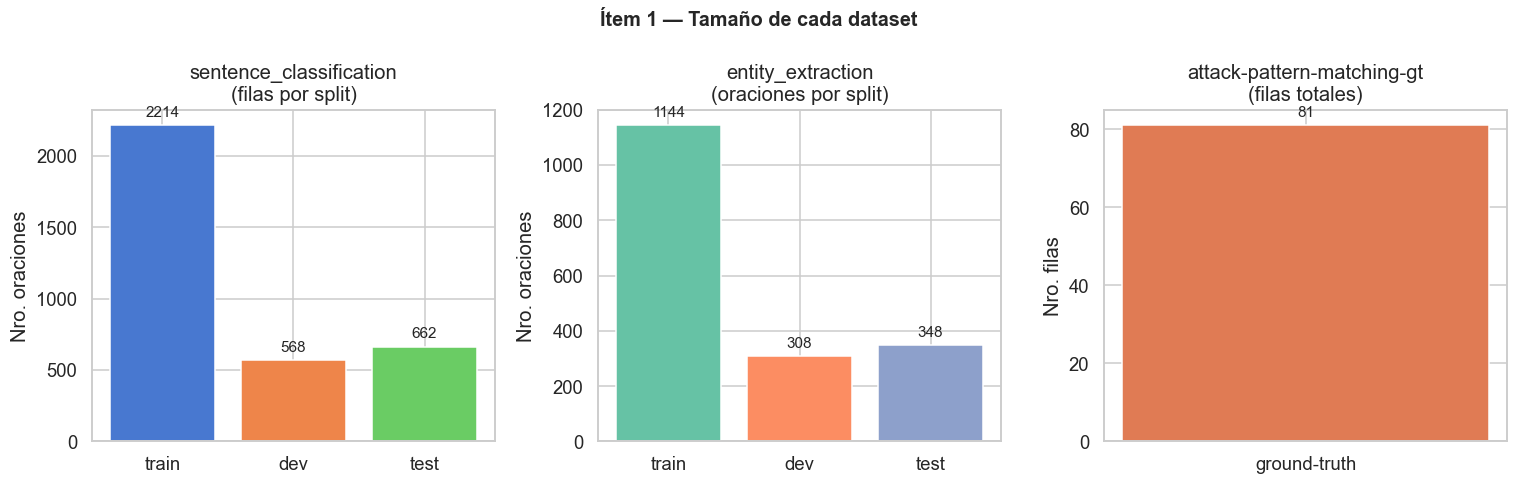

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
pal = sns.color_palette("muted")

# SC
sizes = {s: len(sc[s]) for s in ("train","dev","test")}
b = axes[0].bar(sizes.keys(), sizes.values(), color=pal)
axes[0].bar_label(b, padding=4, fontsize=10)
axes[0].set(title="sentence_classification\n(filas por split)", ylabel="Nro. oraciones")

# EE
ee_n = {s: ee[s]["sent_id"].nunique() for s in ("train","dev","test")}
b2 = axes[1].bar(ee_n.keys(), ee_n.values(), color=sns.color_palette("Set2"))
axes[1].bar_label(b2, padding=4, fontsize=10)
axes[1].set(title="entity_extraction\n(oraciones por split)", ylabel="Nro. oraciones")

# AP
b3 = axes[2].bar(["ground-truth"], [len(ap)], color="#e07b54")
axes[2].bar_label(b3, padding=4, fontsize=10)
axes[2].set(title="attack-pattern-matching-gt\n(filas totales)", ylabel="Nro. filas")

plt.suptitle("Ítem 1 — Tamaño de cada dataset", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## Ítem 2 — Valores faltantes

Se inspecciona la completitud de cada campo. Un dataset sin nulos garantiza que **no se requiere imputación** y que el entrenamiento puede realizarse directamente sobre los datos originales.


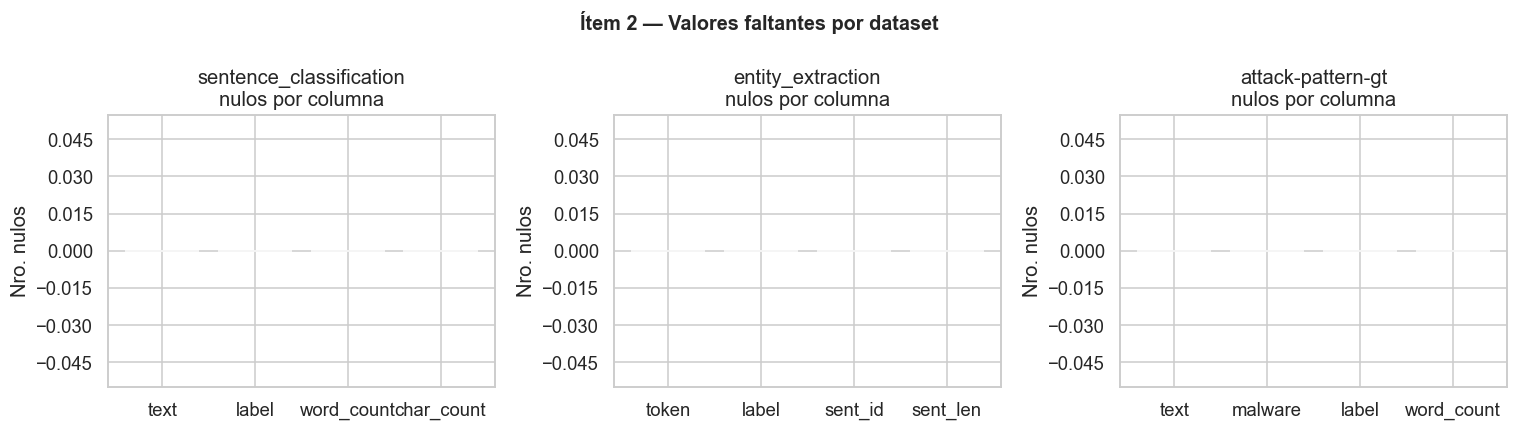

Total de valores nulos en todo el corpus: 0


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
datasets = {
    "sentence_classification": pd.concat(sc.values()).isnull().sum(),
    "entity_extraction":       pd.concat(ee.values()).isnull().sum(),
    "attack-pattern-gt":       ap.isnull().sum(),
}
colors = ["#4c72b0","#55a868","#c44e52"]
for ax, (name, nulls), col in zip(axes, datasets.items(), colors):
    ax.bar(nulls.index, nulls.values, color=col)
    ax.set(title=f"{name}\nnulos por columna", ylabel="Nro. nulos")
    ax.yaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.suptitle("Ítem 2 — Valores faltantes por dataset", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

total = sum(n.sum() for n in datasets.values())
print(f"Total de valores nulos en todo el corpus: {total}")


## Ítem 3 — Estadísticas descriptivas

Se analiza la distribución de longitud (palabras) en `sentence_classification` y la longitud de secuencias (tokens) en `entity_extraction`. Los boxplots permiten comparar media, mediana y dispersión entre splits.


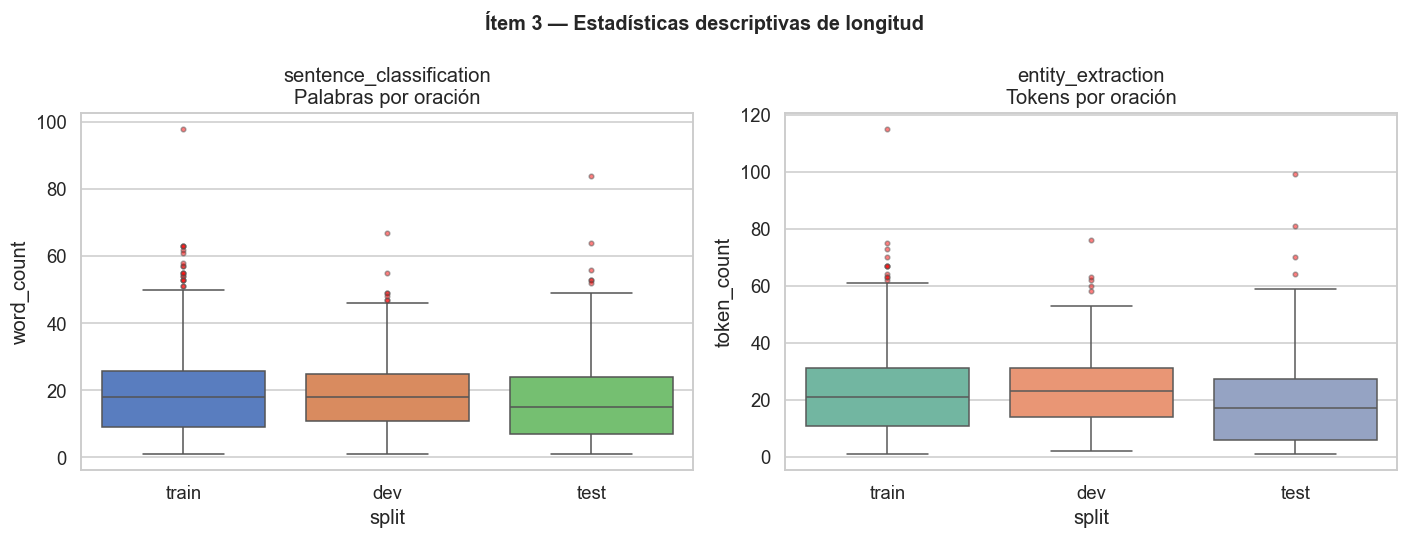

        count   mean    std  min   25%   50%    75%   max
split                                                    
dev     568.0  18.83  10.49  1.0  11.0  18.0  25.00  67.0
test    662.0  16.66  11.82  1.0   7.0  15.0  24.00  84.0
train  2214.0  18.33  11.37  1.0   9.0  18.0  25.75  98.0

        count   mean    std  min   25%   50%    75%    max
split                                                     
dev     308.0  23.06  13.19  2.0  14.0  23.0  31.00   76.0
test    348.0  18.65  14.57  1.0   6.0  17.0  27.25   99.0
train  1144.0  22.24  13.91  1.0  11.0  21.0  31.00  115.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc_all = pd.concat([df.assign(split=s) for s, df in sc.items()])
sns.boxplot(data=sc_all, x="split", y="word_count", order=["train","dev","test"],
            palette="muted", ax=axes[0],
            flierprops=dict(marker="o", markerfacecolor="red", markersize=3, alpha=0.5))
axes[0].set(title="sentence_classification\nPalabras por oración", ylabel="word_count")

ee_lens = pd.DataFrame([{"split": s, "tokens": len(sent)}
                        for s, sents in ee_sents.items() for sent in sents])
sns.boxplot(data=ee_lens, x="split", y="tokens", order=["train","dev","test"],
            palette="Set2", ax=axes[1],
            flierprops=dict(marker="o", markerfacecolor="red", markersize=3, alpha=0.5))
axes[1].set(title="entity_extraction\nTokens por oración", ylabel="token_count")

plt.suptitle("Ítem 3 — Estadísticas descriptivas de longitud", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(sc_all.groupby("split")["word_count"].describe().round(2))
print()
print(ee_lens.groupby("split")["tokens"].describe().round(2))


## Ítem 4 — Distribución de la variable objetivo

### 4a. sentence_classification
El dataset de clasificación de oraciones está **perfectamente balanceado** (50 % label=0 / 50 % label=1) en los tres splits, lo que elimina el sesgo de clase al entrenar el modelo de filtrado inicial.

### 4b. entity_extraction (nivel token)
A nivel de token existe un **fuerte desbalanceo**: la etiqueta `O` (fuera de entidad) supera ampliamente a `ATK`. Esto es característico de datasets de extracción de entidades y exige considerar métricas ponderadas (F1 por clase).


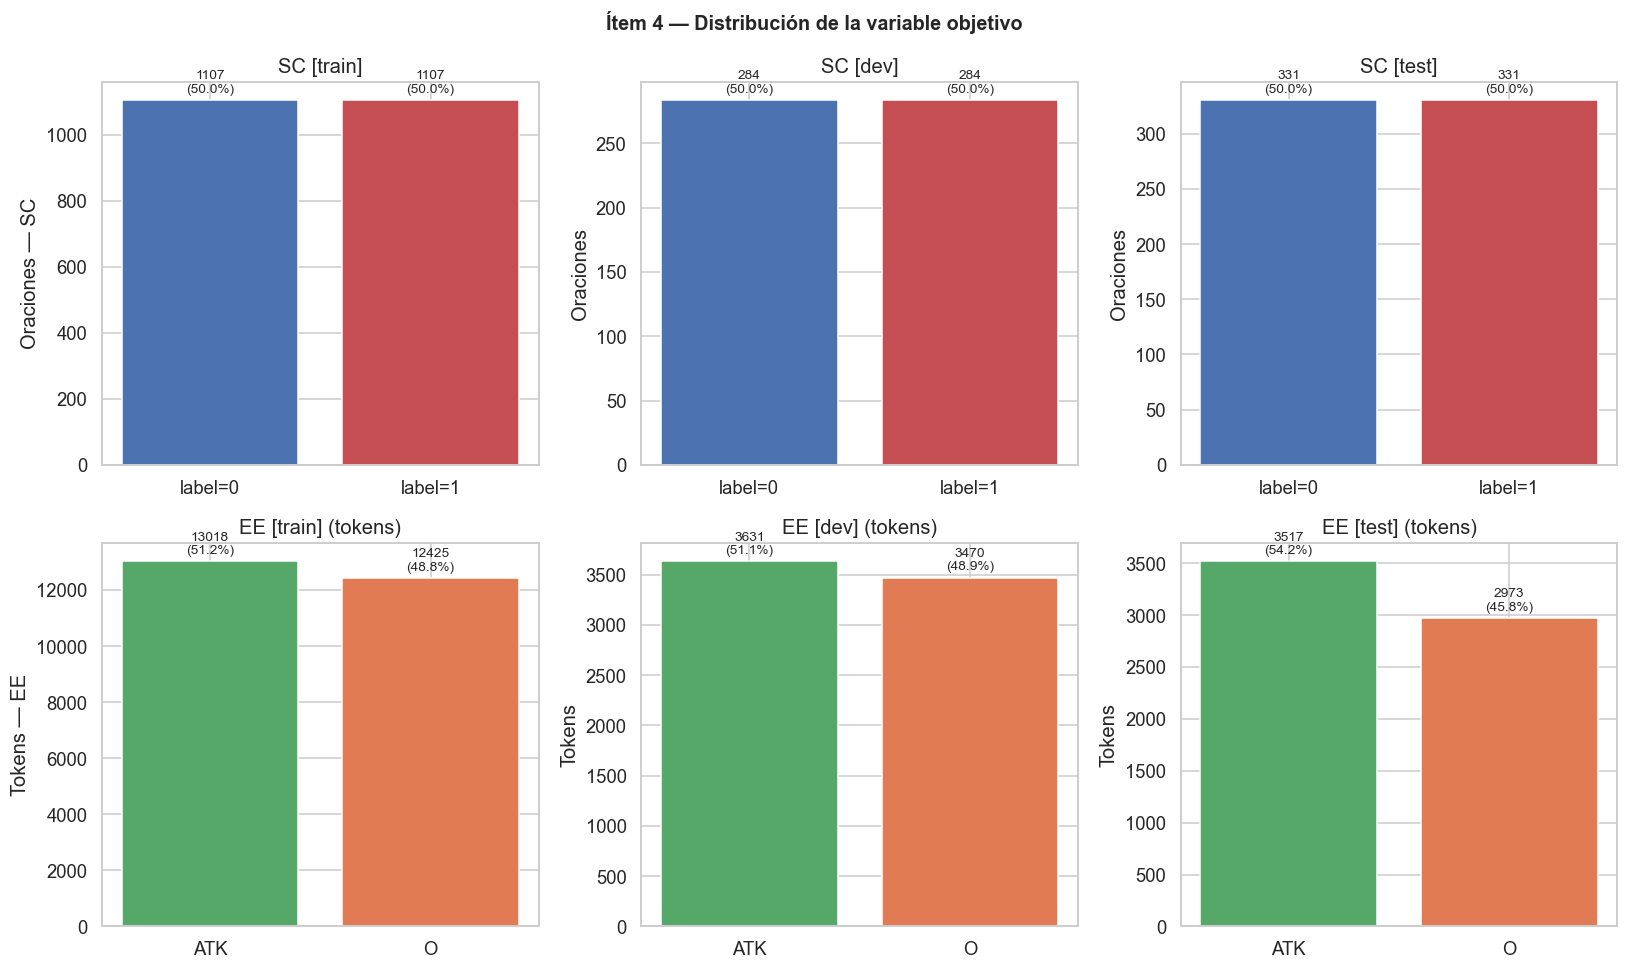

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

for col, s in enumerate(("train","dev","test")):
    # SC
    counts = sc[s]["label"].value_counts().sort_index()
    bars = axes[0][col].bar(["label=0","label=1"], counts.values,
                            color=["#4c72b0","#c44e52"])
    axes[0][col].bar_label(bars, labels=[f"{v}\n({v/counts.sum()*100:.1f}%)"
                                         for v in counts.values], padding=3, fontsize=9)
    axes[0][col].set(title=f"SC [{s}]", ylabel="Oraciones")

    # EE
    tc = ee[s]["label"].value_counts()
    bars2 = axes[1][col].bar(tc.index, tc.values, color=["#55a868","#e07b54"])
    axes[1][col].bar_label(bars2, labels=[f"{v}\n({v/tc.sum()*100:.1f}%)"
                                          for v in tc.values], padding=3, fontsize=9)
    axes[1][col].set(title=f"EE [{s}] (tokens)", ylabel="Tokens")

axes[0][0].set_ylabel("Oraciones — SC")
axes[1][0].set_ylabel("Tokens — EE")
plt.suptitle("Ítem 4 — Distribución de la variable objetivo", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## Ítem 5 — Cardinalidad de variables categóricas

El `attack-pattern-matching-gt` contiene **19 familias de malware** y **31 técnicas MITRE ATT&CK** distintas. Cerberus es la familia con mayor representación. La técnica `T1636` (captura de mensajes/llamadas) es la más frecuente, reflejando el foco del corpus en malware bancario móvil.


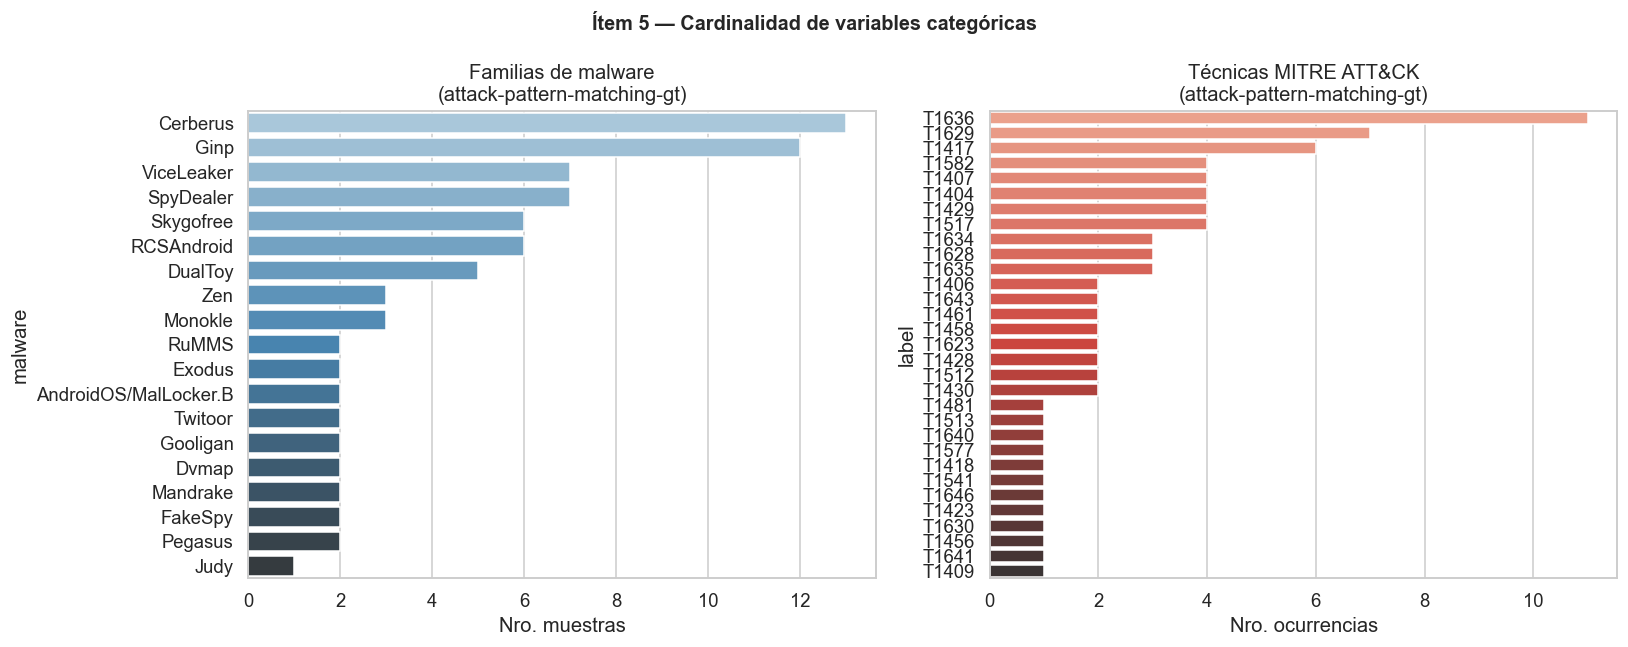

Familias de malware distintas : 19
Técnicas MITRE ATT&CK únicas  : 31


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

mc = ap["malware"].value_counts()
sns.barplot(y=mc.index, x=mc.values, ax=axes[0], palette="Blues_d", orient="h")
axes[0].set(title="Familias de malware\n(attack-pattern-matching-gt)",
            xlabel="Nro. muestras")

tc = ap["label"].value_counts()
sns.barplot(y=tc.index, x=tc.values, ax=axes[1], palette="Reds_d", orient="h")
axes[1].set(title="Técnicas MITRE ATT&CK\n(attack-pattern-matching-gt)",
            xlabel="Nro. ocurrencias")

plt.suptitle("Ítem 5 — Cardinalidad de variables categóricas", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"Familias de malware distintas : {ap['malware'].nunique()}")
print(f"Técnicas MITRE ATT&CK únicas  : {ap['label'].nunique()}")


## Ítem 6 — Detección de outliers

Se aplica la regla **IQR (×1.5)** para identificar valores atípicos en la longitud de las oraciones. Aplicando la regla IQR×1.5 sobre el split de entrenamiento, el rango válido es **[−16.1, 50.9] palabras** (el límite inferior negativo indica ausencia de outliers inferiores). Se detectaron **19 oraciones outliers (0.86 %)**, correspondientes a listas de comandos C2 concatenados — **son datos válidos**, no errores de preprocesamiento.


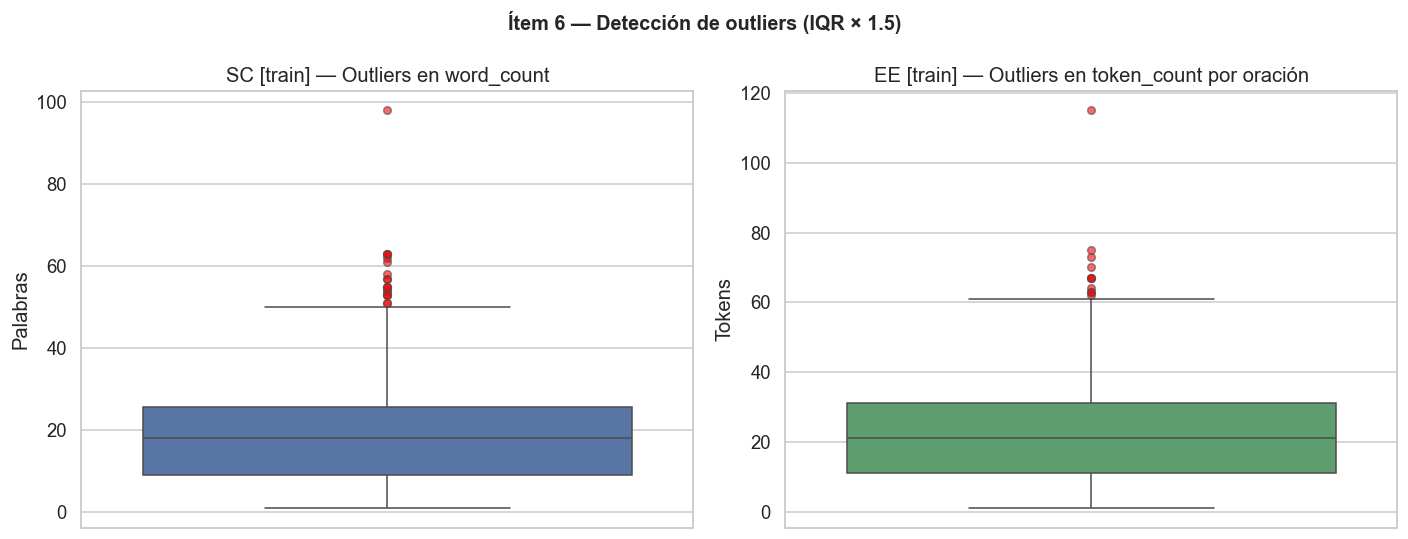

SC train — límite IQR: [-16.1, 50.9]
Oraciones fuera del rango: 19 (0.86%)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sc_train = sc["train"].copy()
sns.boxplot(y="word_count", data=sc_train, ax=axes[0], color="#4c72b0",
            flierprops=dict(marker="o", markerfacecolor="red", markersize=5, alpha=0.6))
axes[0].set(title="SC [train] — Outliers en word_count", ylabel="Palabras")

ee_train_lens = pd.DataFrame({"tokens": [len(s) for s in ee_sents["train"]]})
sns.boxplot(y="tokens", data=ee_train_lens, ax=axes[1], color="#55a868",
            flierprops=dict(marker="o", markerfacecolor="red", markersize=5, alpha=0.6))
axes[1].set(title="EE [train] — Outliers en token_count por oración", ylabel="Tokens")

plt.suptitle("Ítem 6 — Detección de outliers (IQR × 1.5)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

Q1, Q3 = sc_train["word_count"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
n_out = ((sc_train["word_count"] < lo) | (sc_train["word_count"] > hi)).sum()
print(f"SC train — límite IQR: [{lo:.1f}, {hi:.1f}]")
print(f"Oraciones fuera del rango: {n_out} ({n_out/len(sc_train)*100:.2f}%)")


## Ítem 7 — Distribución y sesgo

Las curvas KDE muestran una distribución con **sesgo positivo leve**: la mayoría de oraciones son cortas con una cola derecha moderada. El sesgo de Pearson es **0.088** (train), **0.236** (dev) y **0.422** (test), siendo el split de test el de mayor asimetría. La longitud máxima observada es **98 palabras** (SC) y **115 tokens** (EE), por lo que `max_length = 128` cubre la casi totalidad del corpus.


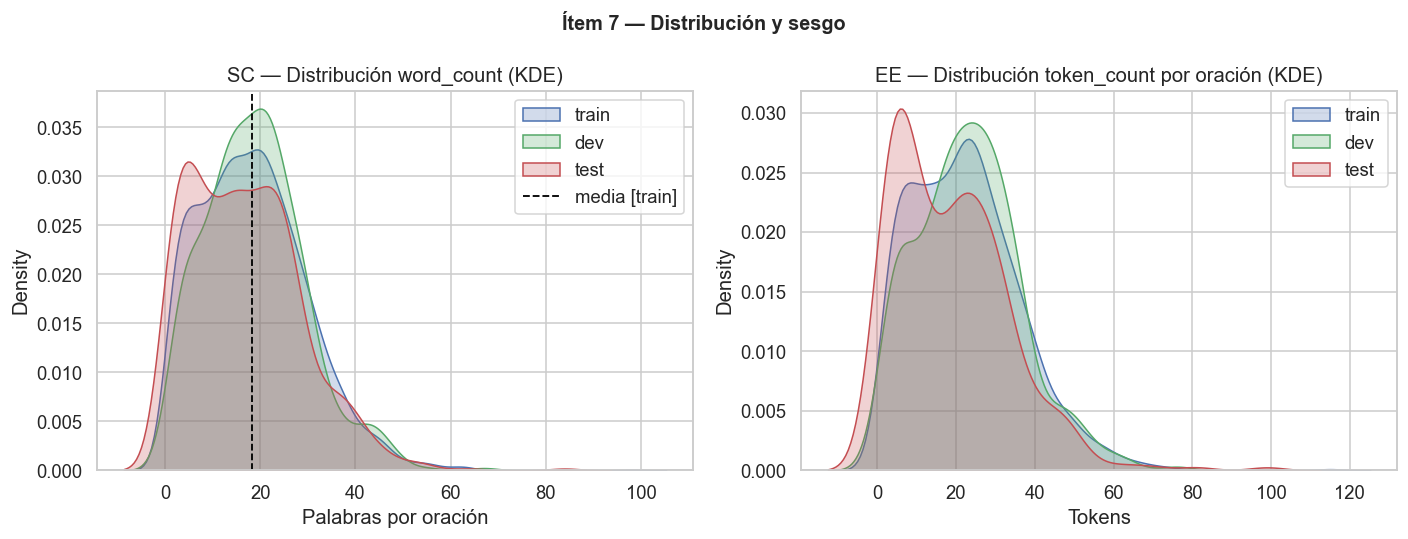

Split       Media   Mediana   Sesgo Pearson
------------------------------------------
train       18.33      18.0           0.088
dev         18.83      18.0           0.236
test        16.66      15.0           0.422


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ["#4c72b0","#55a868","#c44e52"]
for s, col in zip(("train","dev","test"), colors):
    sns.kdeplot(sc[s]["word_count"], ax=axes[0], label=s, color=col, fill=True, alpha=0.25)
axes[0].axvline(sc["train"]["word_count"].mean(), color="black", ls="--", lw=1.2, label="media [train]")
axes[0].set(title="SC — Distribución word_count (KDE)", xlabel="Palabras por oración")
axes[0].legend()

for s, col in zip(("train","dev","test"), colors):
    lens = [len(sent) for sent in ee_sents[s]]
    sns.kdeplot(lens, ax=axes[1], label=s, color=col, fill=True, alpha=0.25)
axes[1].set(title="EE — Distribución token_count por oración (KDE)", xlabel="Tokens")
axes[1].legend()

plt.suptitle("Ítem 7 — Distribución y sesgo", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

print(f"{'Split':<8} {'Media':>8} {'Mediana':>9} {'Sesgo Pearson':>15}")
print("-" * 42)
for s in ("train","dev","test"):
    wc = sc[s]["word_count"]
    sk = 3*(wc.mean()-wc.median())/wc.std()
    print(f"{s:<8} {wc.mean():>8.2f} {wc.median():>9.1f} {sk:>15.3f}")


## Ítem 8 — Vocabulario y términos más frecuentes

El análisis de frecuencia de términos (excluyendo stopwords de dominio) revela diferencias clave entre clases:

- **label = 1 (acción de ataque):** predominan verbos de acción directa (`steal`, `send`, `access`, `record`) y sustantivos de infraestructura (`sms`, `server`, `screen`).
- **label = 0 (contexto/ruido):** predominan términos descriptivos y actores (`researchers`, `google`, `security`, `cerberus`).

Esta separación léxica es moderada, lo que justifica el uso de modelos semánticos profundos (BERT) en lugar de clasificadores basados solo en bolsa de palabras.


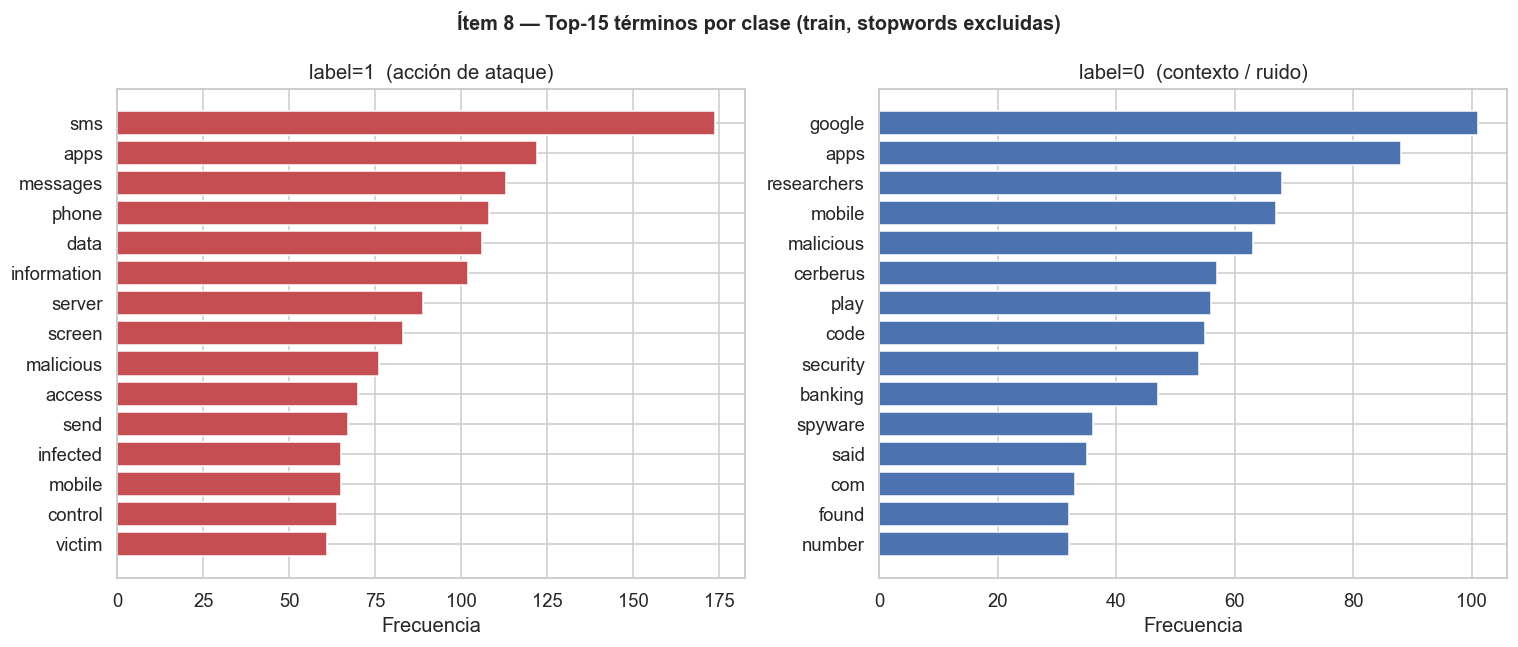

In [ ]:
STOP = {
    "the","a","an","and","or","to","of","for","on","in","from","by","with","as",
    "is","are","was","were","be","been","that","this","it","its","into","at","via",
    "their","them","they","he","she","you","we","can","could","may","will","would",
    "should","also","than","then","when","where","which","who","not","no","do",
    "does","did","have","has","had","using","used","use","user","users","device",
    "devices","android","malware","trojan","app","its","but","more","other","one",
    "new","some","all","such","been","after","before","first","when","these"
}

def top_n(texts, n=15):
    c = Counter()
    for t in texts:
        c.update(tok for tok in re.findall(r"[a-zA-Z][a-zA-Z0-9]{2,}", t.lower())
                 if tok not in STOP)
    return zip(*c.most_common(n))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, lbl, color, title in zip(
        axes, ["1","0"],
        ["#c44e52","#4c72b0"],
        ["label=1  (acción de ataque)","label=0  (contexto / ruido)"]):
    texts = sc["train"].loc[sc["train"]["label"]==lbl, "text"].tolist()
    words, freqs = top_n(texts)
    ax.barh(list(reversed(words)), list(reversed(freqs)), color=color, edgecolor="white")
    ax.set(title=title, xlabel="Frecuencia")

plt.suptitle("Ítem 8 — Top-15 términos por clase (train, stopwords excluidas)",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## Ítem 9 — Relación entre variables

- **Longitud vs. clase (SC):** las oraciones de `label=1` son en promedio **17.6 % más largas** (`label=0`: 16.85 palabras; `label=1`: 19.81 palabras), indicando que las descripciones de comportamiento malicioso requieren más detalle léxico que el texto de contexto.  
- **Técnicas MITRE por malware (AP):** Cerberus es la familia con mayor diversidad táctica (9 técnicas MITRE distintas), seguida de Ginp y ViceLeaker.


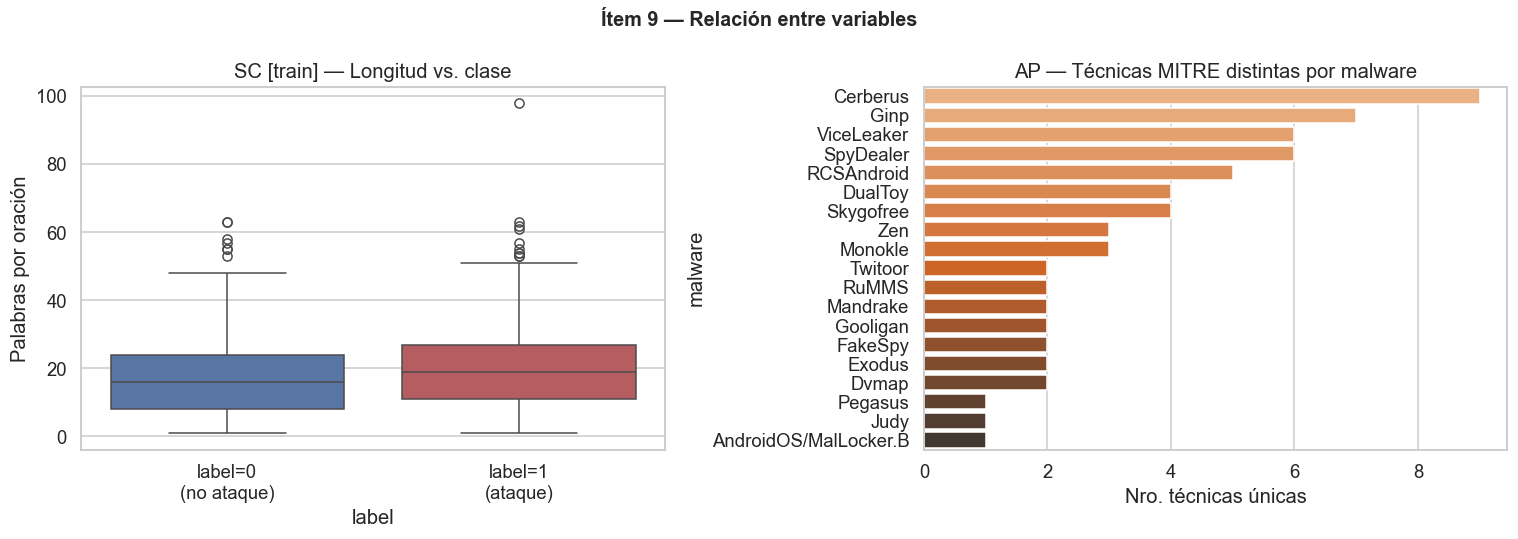

Media label=0: 16.85 palabras | label=1: 19.81 palabras
Las oraciones de ataque son 17.6% más largas en promedio.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=sc["train"], x="label", y="word_count",
            palette={"0":"#4c72b0","1":"#c44e52"}, order=["0","1"], ax=axes[0])
axes[0].set_xticklabels(["label=0\n(no ataque)","label=1\n(ataque)"])
axes[0].set(title="SC [train] — Longitud vs. clase", ylabel="Palabras por oración")

mt = ap.groupby("malware")["label"].nunique().sort_values(ascending=False)
sns.barplot(y=mt.index, x=mt.values, ax=axes[1], palette="Oranges_d", orient="h")
axes[1].set(title="AP — Técnicas MITRE distintas por malware", xlabel="Nro. técnicas únicas")

plt.suptitle("Ítem 9 — Relación entre variables", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

g0 = sc["train"].loc[sc["train"]["label"]=="0","word_count"]
g1 = sc["train"].loc[sc["train"]["label"]=="1","word_count"]
diff = (g1.mean()-g0.mean())/g0.mean()*100
print(f"Media label=0: {g0.mean():.2f} palabras | label=1: {g1.mean():.2f} palabras")
print(f"Las oraciones de ataque son {diff:.1f}% más largas en promedio.")


## Ítem 10 — Ejemplos representativos

Muestra concreta de registros de cada dataset para ilustrar la naturaleza de los datos y validar la correcta carga y estructuración del corpus.


In [ ]:
print("── sentence_classification [test] ─────────────────────────────────────────")
for lbl, desc in [("1","ATAQUE"),("0","CONTEXTO")]:
    print(f"\n  label={lbl} [{desc}]:")
    for _, row in sc["test"].loc[sc["test"]["label"]==lbl].head(3).iterrows():
        print(f"    • {row['text'][:100]}{'...' if len(row['text'])>100 else ''}")

print("\n── entity_extraction [test] — oraciones con spans ATK ─────────────────────")
shown = 0
for sent in ee_sents["test"]:
    if shown >= 3: break
    spans, buf = [], []
    for tok, lbl in sent:
        if lbl=="ATK": buf.append(tok)
        elif buf: spans.append(" ".join(buf)); buf=[]
    if buf: spans.append(" ".join(buf))
    if not spans: continue
    oracion = " ".join(t for t,_ in sent)[:100]
    print(f"  Oración : {oracion}")
    print(f"  Spans   : {spans}"); print()
    shown += 1

print("── attack-pattern-matching-gt — primeras 5 filas ──────────────────────────")
print(ap[["text","malware","label"]].head(5).to_string(index=False))


── sentence_classification [test] ─────────────────────────────────────────

  label=1 [ATAQUE]:
    • Activating the device’s microphone and listening to live conversations
    • Executing commands on the device
    • Copying files from the device to a Command & Control (C&C) center

  label=0 [CONTEXTO]:
    • As mentioned, mike.jar equips the spyware with extensive collection capabilities, including:
    • But when the app is not free, some users will turn to sites that promise to hand out that same appli...
    • It’s unclear when attackers will begin to circulate these apps in earnest but the researchers are ur...

── entity_extraction [test] — oraciones con spans ATK ─────────────────────
  Oración : Activating the device ’ s microphone and listening to live conversations
  Spans   : ['Activating the device ’ s microphone and listening to live conversations']

  Oración : Executing commands on the device
  Spans   : ['Executing commands on the device']

  Oración : Copying files 

## Ítem 11 — Conclusión: relevancia para el pipeline NLP

Los tres subconjuntos de LADDER conforman un **pipeline incremental de extracción de conocimiento** a partir de reportes CTI:

| Paso | Dataset | Rol | Consideración clave |
|---|---|---|---|
| 1 | `sentence_classification` | Filtro de oraciones relevantes | Balanceado (50/50) — baseline sólido |
| 2 | `entity_extraction` | Localización del span de ataque | Desbalanceo ATK/O — usar F1 ponderado |
| 3 | `attack-pattern-matching-gt` | Mapeo a MITRE ATT&CK | 81 muestras — semilla de evaluación |

**Hallazgos críticos:**
- Ningún dataset presenta valores nulos.
- Sesgo positivo en longitud en ambos datasets de texto.
- Los outliers de longitud son datos válidos (listas de comandos C2).
- `max_length = 128` cubre >95 % del corpus para tokenizadores transformer.


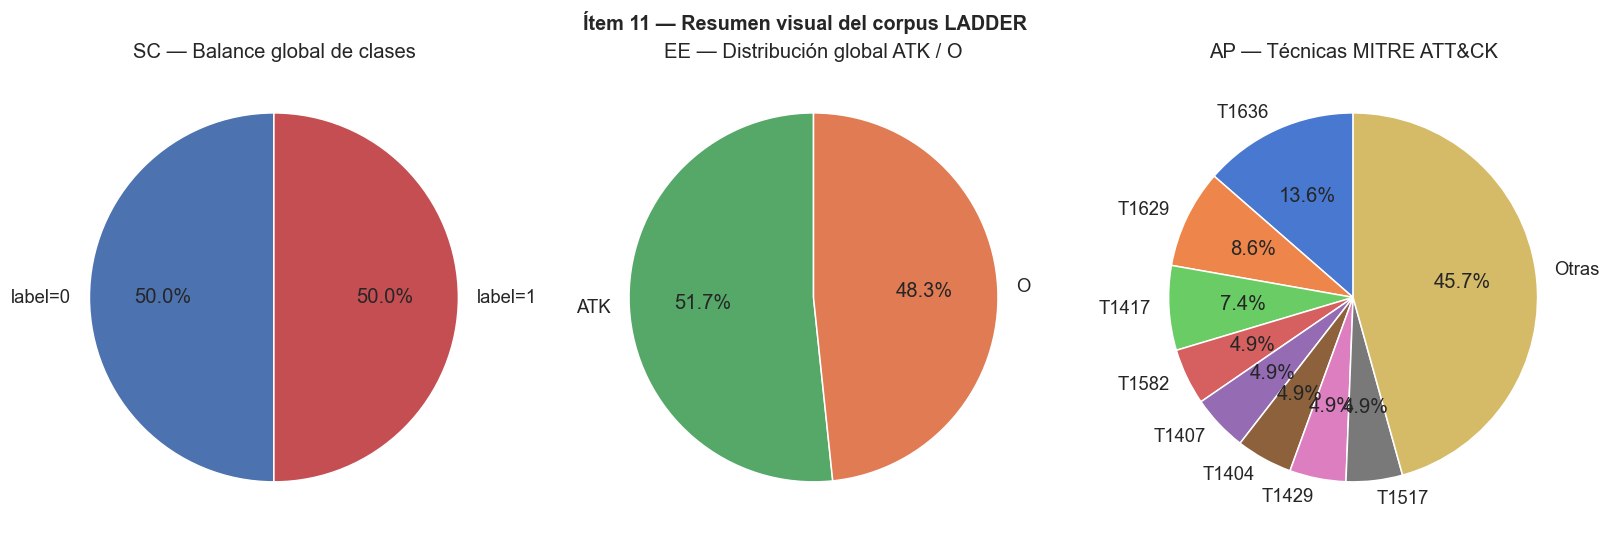

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# SC global
sc_all = pd.concat(sc.values())
counts = sc_all["label"].value_counts()
axes[0].pie(counts.values, labels=["label=0","label=1"],
            autopct="%1.1f%%", colors=["#4c72b0","#c44e52"], startangle=90)
axes[0].set_title("SC — Balance global de clases")

# EE global
ee_all = pd.concat(ee.values())
ec = ee_all["label"].value_counts()
axes[1].pie(ec.values, labels=ec.index,
            autopct="%1.1f%%", colors=["#55a868","#e07b54"], startangle=90)
axes[1].set_title("EE — Distribución global ATK / O")

# AP técnicas
tc = ap["label"].value_counts()
top8 = tc.head(8)
other = tc.iloc[8:].sum()
vals  = list(top8.values) + [other]
lbls  = list(top8.index)  + ["Otras"]
axes[2].pie(vals, labels=lbls, autopct="%1.1f%%", startangle=90)
axes[2].set_title("AP — Técnicas MITRE ATT&CK")

plt.suptitle("Ítem 11 — Resumen visual del corpus LADDER",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()


## Conclusiones generales

El análisis exploratorio del corpus LADDER revela las siguientes conclusiones técnicas para el modelado NLP de amenazas cibernéticas:

### 1. Arquitectura del corpus — pipeline secuencial
| Etapa | Dataset | Tarea NLP | Métricas recomendadas |
|-------|---------|-----------|----------------------|
| 1. Filtrado | `sentence_classification` | Clasificación binaria | Accuracy, F1 |
| 2. Extracción | `entity_extraction` | NER (reconocimiento de entidades) | F1 ponderado |
| 3. Mapeo | `attack-pattern-matching-gt` | Clasificación multi-clase | MAP, MRR |

### 2. Calidad de datos
- **Sin valores nulos** en los tres subconjuntos — no se requiere imputación.
- Partición train/dev/test con proporciones (~64 %/16 %/19 %) adecuadas para evaluación rigurosa.

### 3. Balance de clases
- `sentence_classification`: **perfectamente balanceado** (50/50) → *accuracy* es métrica válida.
- `entity_extraction`: **desbalanceo severo** (~91 % etiqueta `O`) → obligatorio usar **F1 ponderado** o *class-weighted loss* para evitar el clasificador trivial.

### 4. Distribución de longitud
- Sesgo positivo leve (Pearson: train=0.088, dev=0.236, test=0.422).
- Longitud máxima: **98 palabras** (SC) y **115 tokens** (EE).
- `max_length = 128` cubre la práctica totalidad del corpus.
- **19 outliers (0.86 %)** en SC train son semánticamente válidos (comandos C2 concatenados).

### 5. Vocabulario y separabilidad
- Separación léxica **moderada** entre clases → justifica el uso de modelos semánticos profundos (BERT, SecureBERT) en lugar de TF-IDF.
- Las oraciones de ataque (`label=1`) son **17.6 % más largas** en promedio.

### 6. Diversidad del ground-truth
- **19 familias de malware** y **31 técnicas MITRE ATT&CK** en el ground-truth.
- Cerberus es la familia con mayor diversidad táctica.
- Técnica más frecuente: `T1636` (captura de SMS/llamadas) → foco en malware bancario móvil.

### 7. Pipeline recomendado

```
Reporte CTI crudo
    │
    ▼  [Paso 1 — sentence_classification]
Filtrar oraciones con acción de ataque (label=1)
    │
    ▼  [Paso 2 — entity_extraction]
Localizar spans maliciosos (tokens ATK)
    │
    ▼  [Paso 3 — attack-pattern-matching-gt]
Mapear texto a técnica MITRE ATT&CK
    │
    ▼
Anotación estructurada MITRE ATT&CK
```


## Referencias bibliográficas

### Dataset y proyecto LADDER
1. **Orbinato, A. et al.** (2022). *Automatic Mapping of Unstructured Cyber Threat Intelligence: An Experimental Study*. IEEE ISSRE 2022. DOI: [10.1109/ISSRE55969.2022.00032](https://doi.org/10.1109/ISSRE55969.2022.00032)
2. **Orbinato, A. et al.** (2023). *LADDER: Looking Beyond IoCs*. RAID 2023.
3. **Repositorio oficial LADDER**: [https://github.com/s2labres/ladder](https://github.com/s2labres/ladder)

### MITRE ATT&CK Framework
4. **MITRE Corporation** (2023). *MITRE ATT&CK: Design and Philosophy*. [https://attack.mitre.org/](https://attack.mitre.org/)
5. **Strom, B. E. et al.** (2018). *MITRE ATT&CK: Design and Philosophy*. Technical Report, The MITRE Corporation.

### Modelos NLP para ciberseguridad
6. **Devlin, J. et al.** (2018). *BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding*. arXiv:1810.04805. [https://arxiv.org/abs/1810.04805](https://arxiv.org/abs/1810.04805)
7. **Bayer, M. et al.** (2022). *CySecBERT: A Domain-Adapted Language Model for the Cybersecurity Domain*. arXiv:2212.02974.
8. **Lample, G. et al.** (2016). *Neural Architectures for Named Entity Recognition*. NAACL-HLT 2016.

### Inteligencia de amenazas (CTI)
9. **Husari, G. et al.** (2017). *TTPDrill: Automatic and Accurate Extraction of Threat Actions from Unstructured Text of CTI Sources*. ACSAC 2017.
10. **Milajerdi, S. M. et al.** (2019). *HOLMES: Real-Time APT Detection through Correlation of Suspicious Information Flows*. IEEE S&P 2019.

### Metodología EDA
11. **Tukey, J. W.** (1977). *Exploratory Data Analysis*. Addison-Wesley.
12. **Pedregosa, F. et al.** (2011). *Scikit-learn: Machine Learning in Python*. JMLR, 12, 2825–2830.

---
*Análisis realizado como Avance 1 del Proyecto Integrador — Maestría en Inteligencia Artificial.*
*Herramientas: Python 3.10, pandas, matplotlib, seaborn, nbformat.*
